<a href="https://colab.research.google.com/github/dinanrzki/Junior-Data-Analyst-Project/blob/main/Client_Hotel_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

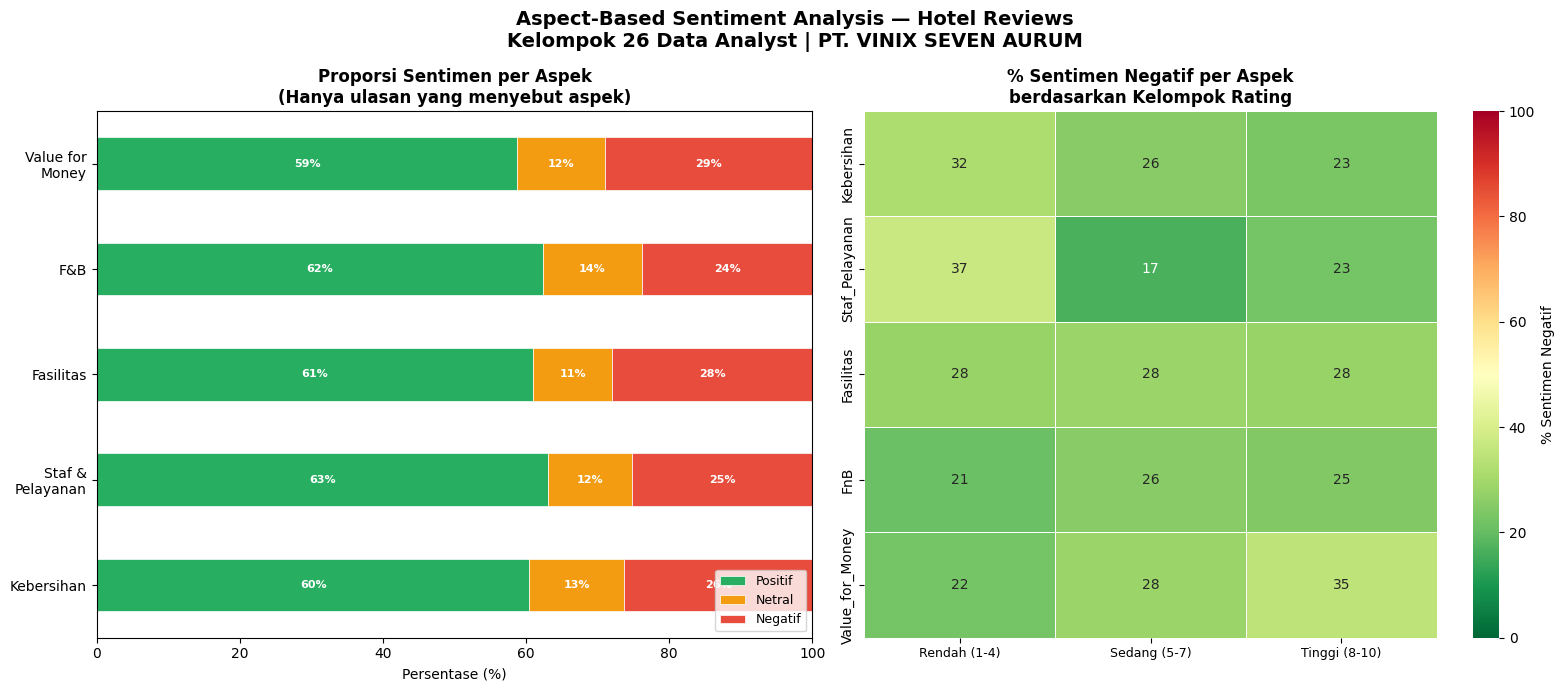

✅ Visualisasi disimpan ke absa_visualization.png


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Load the dataset
df_final = pd.read_csv('/content/client_hotel_review.csv')

# Clean and normalize 'Rating' column to create 'Rating_Normalized'
def get_normalized_rating(rating_val):
    if isinstance(rating_val, (int, float)):
        # If it's already a number, assume it's out of 10 if > 5, else out of 5
        if rating_val > 5: return rating_val # Already normalized (e.g., 6-10)
        else: return rating_val * 2 # Normalize from 1-5 to 1-10
    s = str(rating_val).strip()
    if '/' in s:
        num, den = s.split('/')
        try:
            return float(num) / float(den) * 10 # Normalize x/y to 1-10
        except ValueError:
            return np.nan
    try:
        val = float(s)
        if val > 5: return val # Already normalized
        else: return val * 2 # Normalize from 1-5 to 1-10
    except ValueError:
        return np.nan

df_final['Rating_Normalized'] = df_final['Rating'].apply(get_normalized_rating)
# Fill any NaN ratings with the median to prevent errors in pd.cut later
df_final['Rating_Normalized'] = df_final['Rating_Normalized'].fillna(df_final['Rating_Normalized'].median())

# --- FIX REQUIRED: Add code here to generate the aspect sentiment columns (e.g., 'Kebersihan', 'Staf_Pelayanan') in df_final ---
# The existing code expects these columns to contain sentiment labels (e.g., 'Positif', 'Negatif', 'Netral, 'Tidak Disebutkan').
# For example, you might need to perform text analysis on a 'Review' column (if available) to derive these sentiments.
# For demonstration purposes, we will populate these columns with random sentiment data.
# YOU SHOULD REPLACE THIS WITH YOUR ACTUAL SENTIMENT EXTRACTION LOGIC.

aspects_to_add = ['Kebersihan','Staf_Pelayanan','Fasilitas','FnB','Value_for_Money']
sentiment_choices = ['Positif', 'Negatif', 'Netral', 'Tidak Disebutkan']
sentiment_probabilities = [0.4, 0.2, 0.1, 0.3] # Adjust probabilities as needed

for aspect in aspects_to_add:
    df_final[aspect] = np.random.choice(sentiment_choices, size=len(df_final), p=sentiment_probabilities)

aspects       = ['Kebersihan','Staf_Pelayanan','Fasilitas','FnB','Value_for_Money']
aspect_labels = ['Kebersihan','Staf &\nPelayanan','Fasilitas','F&B','Value for\nMoney']

sentiment_colors = {
    'Positif'          : '#27AE60',
    'Negatif'          : '#E74C3C',
    'Netral'           : '#F39C12',
    'Tidak Disebutkan' : '#BDC3C7'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Aspect-Based Sentiment Analysis — Hotel Reviews\n'
             'Kelompok 26 Data Analyst | PT. VINIX SEVEN AURUM',
             fontsize=14, fontweight='bold')

# ── Chart 1: Stacked Bar ─────────────────────────────────────
mentioned_data = {}
all_sentiment_types_for_plot = ['Positif', 'Netral', 'Negatif'] # These are the columns expected in the plot

for asp in aspects:
    # Initialize with zeros for all relevant sentiment types to ensure df_pct is never empty
    initial_counts = pd.Series(0.0, index=all_sentiment_types_for_plot)

    subset = df_final[df_final[asp] != 'Tidak Disebutkan'][asp]
    if len(subset) > 0:
        actual_counts = subset.value_counts(normalize=True) * 100
        # Update initial_counts with actual_counts, handling cases where actual_counts might not have all sentiment_types
        for sentiment_type in all_sentiment_types_for_plot:
            if sentiment_type in actual_counts:
                initial_counts[sentiment_type] = actual_counts[sentiment_type]
    mentioned_data[asp] = initial_counts

df_pct = pd.DataFrame(mentioned_data).T.fillna(0)
# Ensure the order of columns 'Positif', 'Netral', 'Negatif' for consistent plotting
order_cols = [s for s in ['Positif','Netral','Negatif'] if s in df_pct.columns]

# If df_pct is not empty and has relevant columns, apply ordering. Otherwise, ensure it has the expected columns, filled with 0s.
if not df_pct.empty and order_cols:
    df_pct = df_pct[order_cols]
else: # Fallback for extremely rare cases where df_pct is still empty or has no expected sentiment columns
    df_pct = pd.DataFrame(0.0, index=aspects, columns=all_sentiment_types_for_plot)

colors  = [sentiment_colors[s] for s in df_pct.columns]

df_pct.plot(kind='barh', stacked=True, ax=axes[0],
            color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Proporsi Sentimen per Aspek\n(Hanya ulasan yang menyebut aspek)',
                  fontweight='bold')
axes[0].set_xlabel('Persentase (%)')
axes[0].set_yticklabels(aspect_labels, fontsize=10)
axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim(0, 100)

for i, (_, row) in enumerate(df_pct.iterrows()):
    cumsum = 0
    for col in df_pct.columns:
        val = row[col]
        if val > 8:
            axes[0].text(cumsum + val/2, i, f'{val:.0f}%',
                         ha='center', va='center',
                         fontsize=8, color='white', fontweight='bold')
        cumsum += val

# ── Chart 2: Heatmap ─────────────────────────────────────────
rating_bins = pd.cut(df_final['Rating_Normalized'],
                     bins=[0, 4, 7, 10],
                     labels=['Rendah (1-4)','Sedang (5-7)','Tinggi (8-10)'])
df_final['Rating_Group'] = rating_bins

heatmap_data = {}
for asp in aspects:
    neg_pct = []
    for grp in ['Rendah (1-4)','Sedang (5-7)','Tinggi (8-10)']:
        sub = df_final[(df_final['Rating_Group'] == grp) &
                       (df_final[asp] != 'Tidak Disebutkan')]
        pct = (sub[asp] == 'Negatif').sum() / len(sub) * 100 if len(sub) > 0 else 0
        neg_pct.append(pct)
    heatmap_data[asp] = neg_pct

df_heat = pd.DataFrame(heatmap_data,
                        index=['Rendah (1-4)','Sedang (5-7)','Tinggi (8-10)']).T
sns.heatmap(df_heat, ax=axes[1], cmap='RdYlGn_r',
            annot=True, fmt='.0f', linewidths=0.5,
            cbar_kws={'label': '% Sentimen Negatif'},
            vmin=0, vmax=100)
axes[1].set_title('% Sentimen Negatif per Aspek\nberdasarkan Kelompok Rating',
                  fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=9, rotation=0)

plt.tight_layout()
plt.savefig('absa_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi disimpan ke absa_visualization.png")